In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, silhouette_score
from mlxtend.frequent_patterns import apriori, association_rules
import pickle
 
# Load dataset
df = pd.read_csv("student_productivity_distraction_dataset_20000.csv")
print("First 5 rows:")
print(df.head())
 
print("\nDataset shape:", df.shape)
df.info()
print("\nStatistical summary:")
print(df.describe())
 
# Data cleaning
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
print("\nShape after cleaning:", df.shape)

First 5 rows:
   age  gender  study_hours_per_day  sleep_hours  social_media_hours  \
0   23  Female                 4.35         3.63                2.73   
1   20    Male                 6.14         6.58                1.51   
2   29  Female                 4.98         3.26                3.63   
3   27  Female                 3.19         4.58                3.95   
4   24    Male                 7.67         6.21                1.59   

   gaming_hours  exercise_minutes  assignments_completed  \
0          5.26               111                      2   
1          1.73                28                     10   
2          4.71               102                      8   
3          2.52                28                     18   
4          5.65               105                      7   

   attendance_percentage  stress_level  productivity_score  
0                  57.21            10               33.78  
1                  91.27            10               48.99  
2        

Class labels (sorted): ['High', 'Low', 'Medium']

Encoded DataFrame head:
   age  gender  study_hours_per_day  sleep_hours  social_media_hours  \
0   23  Female                 4.35         3.63                2.73   
1   20    Male                 6.14         6.58                1.51   
2   29  Female                 4.98         3.26                3.63   
3   27  Female                 3.19         4.58                3.95   
4   24    Male                 7.67         6.21                1.59   

   gaming_hours  exercise_minutes  assignments_completed  \
0          5.26               111                      2   
1          1.73                28                     10   
2          4.71               102                      8   
3          2.52                28                     18   
4          5.65               105                      7   

   attendance_percentage  stress_level  productivity_score Productivity  \
0                  57.21            10               33.7

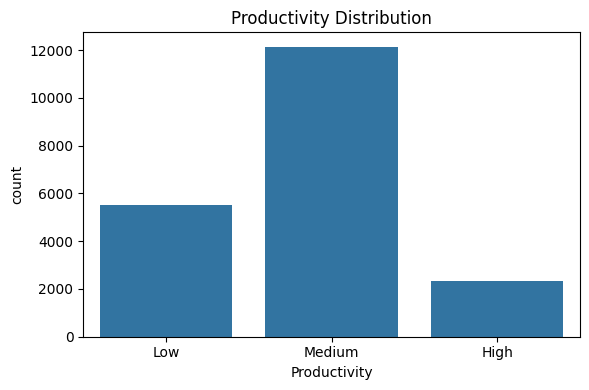

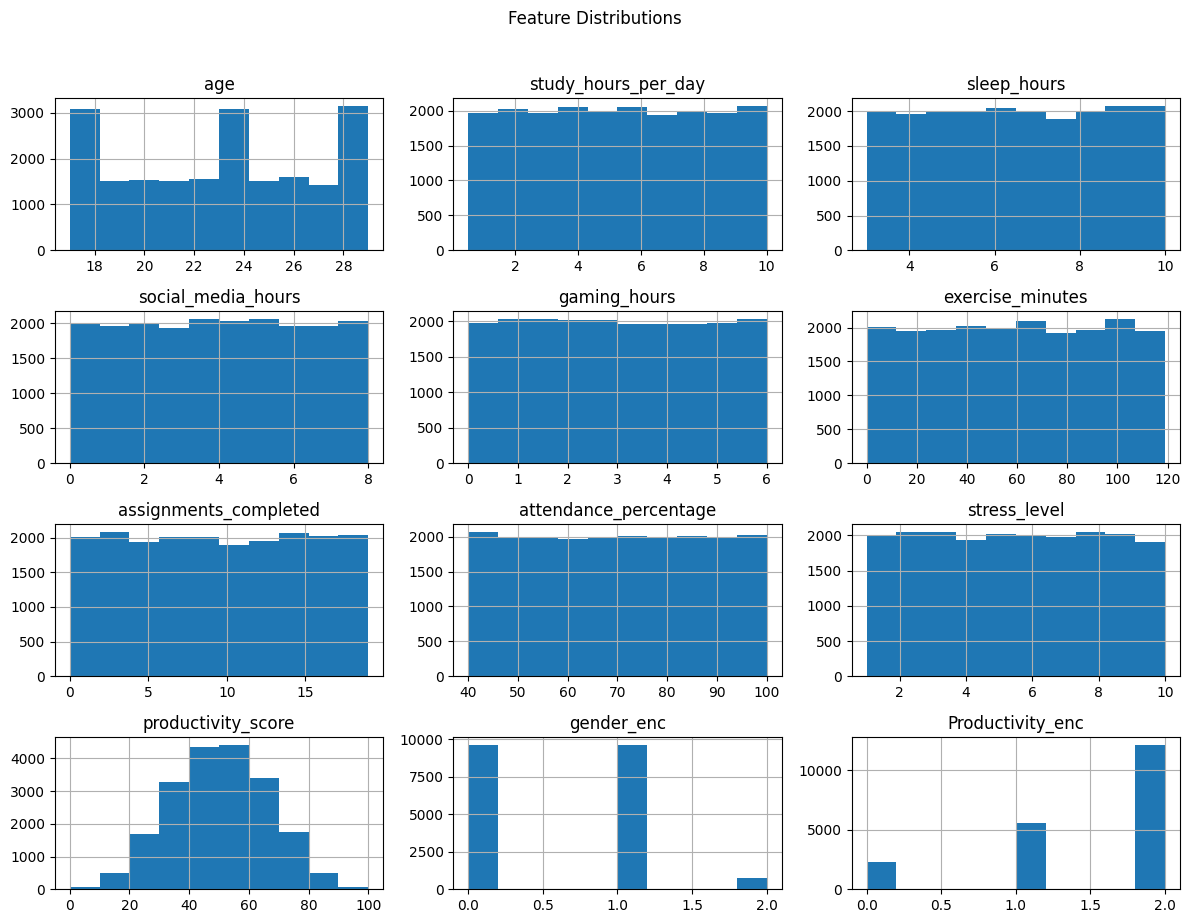

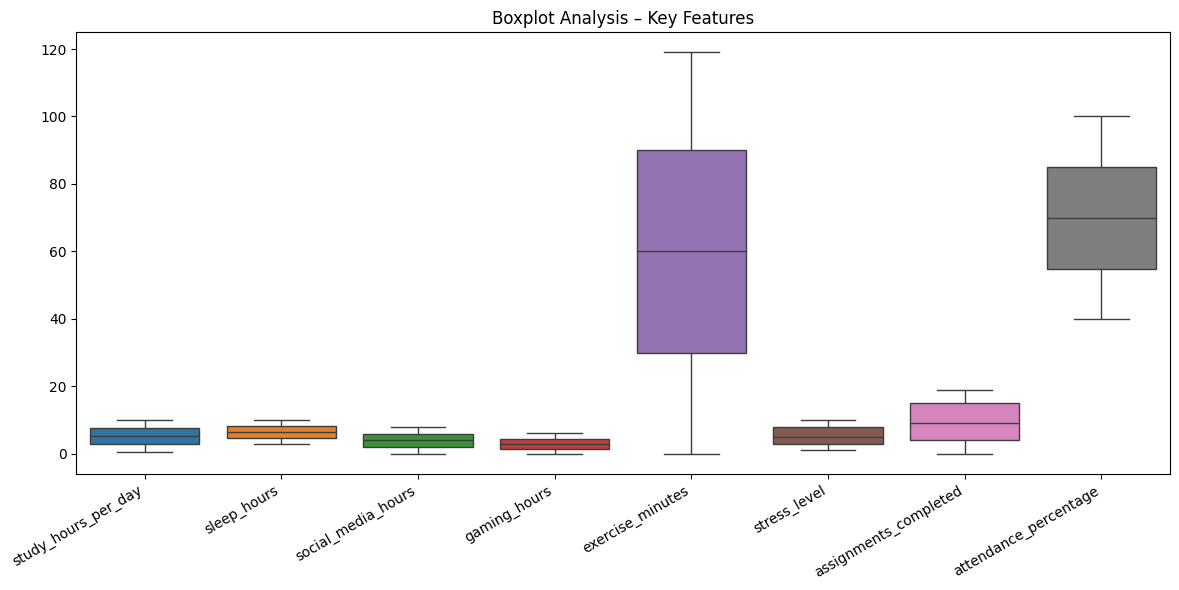


Correlation Matrix:
                        study_hours_per_day  sleep_hours  social_media_hours  \
study_hours_per_day               1.000000     0.001670            0.004888   
sleep_hours                       0.001670     1.000000           -0.005939   
social_media_hours                0.004888    -0.005939            1.000000   
gaming_hours                     -0.002104    -0.003666            0.006406   
exercise_minutes                  0.004380     0.006526           -0.006226   
stress_level                      0.001781     0.000020            0.000355   
assignments_completed             0.005643     0.000944            0.003418   
attendance_percentage            -0.008083     0.003433            0.009388   
productivity_score                0.732777     0.340902            0.001285   

                       gaming_hours  exercise_minutes  stress_level  \
study_hours_per_day       -0.002104          0.004380      0.001781   
sleep_hours               -0.003666          

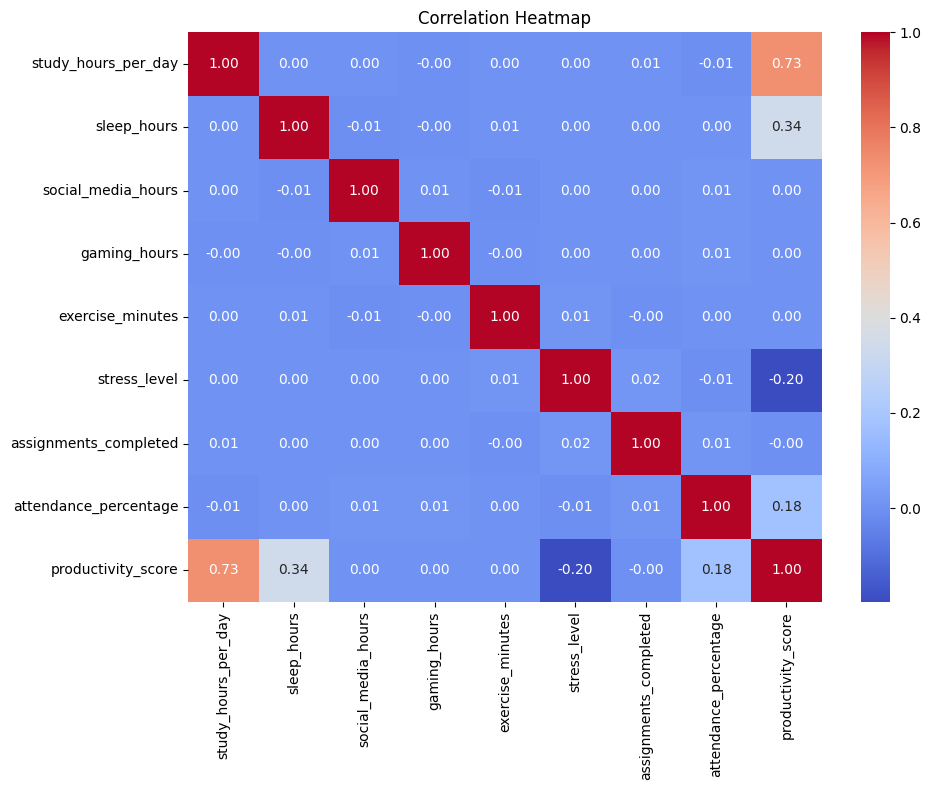

In [3]:
def label_productivity(score):
    if score >= 70:
        return "High"
    elif score >= 40:
        return "Medium"
    else:
        return "Low"
 
df["Productivity"] = df["productivity_score"].apply(label_productivity)
 
# ---------- Encode categorical columns ----------
gender_encoder    = LabelEncoder()
productivity_encoder = LabelEncoder()
 
df["gender_enc"]     = gender_encoder.fit_transform(df["gender"])
df["Productivity_enc"] = productivity_encoder.fit_transform(df["Productivity"])
 
print("Class labels (sorted):", list(productivity_encoder.classes_))
 
print("\nEncoded DataFrame head:")
print(df.head())
 
# ---------- Statistical summaries ----------
numeric_cols = df.select_dtypes(include=np.number).columns
print("\nMean:\n",   df[numeric_cols].mean())
print("\nMedian:\n", df[numeric_cols].median())
print("\nVariance:\n", df[numeric_cols].var())
print("\nStd Dev:\n", df[numeric_cols].std())
 
# Productivity distribution
plt.figure(figsize=(6, 4))
order = ["Low", "Medium", "High"]
sns.countplot(x=df["Productivity"], order=order)
plt.title("Productivity Distribution")
plt.tight_layout()
plt.show()
 
# Histograms
df[numeric_cols].hist(figsize=(12, 9))
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()
 
# Boxplots (key numeric features)
key_features = ["study_hours_per_day", "sleep_hours", "social_media_hours",
                "gaming_hours", "exercise_minutes", "stress_level",
                "assignments_completed", "attendance_percentage"]
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[key_features])
plt.xticks(rotation=30, ha="right")
plt.title("Boxplot Analysis – Key Features")
plt.tight_layout()
plt.show()
 
# Correlation heatmap (numeric only)
corr_df = df[key_features + ["productivity_score"]].corr()
print("\nCorrelation Matrix:\n", corr_df)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Decision Tree Accuracy: 0.73975


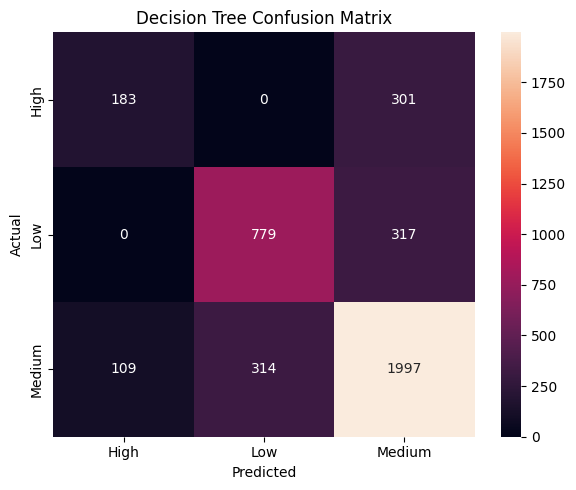

Random Forest Accuracy: 0.7595

Classification Report (Random Forest):
               precision    recall  f1-score   support

        High       0.70      0.45      0.55       484
         Low       0.74      0.69      0.72      1096
      Medium       0.77      0.85      0.81      2420

    accuracy                           0.76      4000
   macro avg       0.74      0.67      0.69      4000
weighted avg       0.76      0.76      0.75      4000


Model Comparison:
            Model  Accuracy
0  Decision Tree   0.73975
1  Random Forest   0.75950

Feature Importance:
                  Feature  Importance
0    study_hours_per_day    0.368535
1            sleep_hours    0.149736
7  attendance_percentage    0.108679
2     social_media_hours    0.082014
3           gaming_hours    0.081938
4       exercise_minutes    0.077299
5           stress_level    0.058850
6  assignments_completed    0.056939
8             gender_enc    0.016011


C:\Users\ALGOR\AppData\Local\Temp\ipykernel_1444\1401130247.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x="Importance", y="Feature", palette="Blues_r")


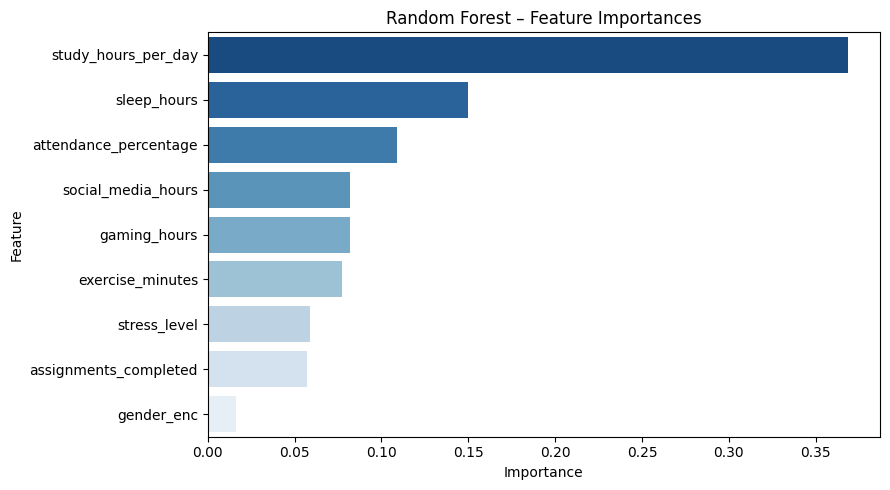

In [4]:
FEATURES = [
    "study_hours_per_day",
    "sleep_hours",
    "social_media_hours",
    "gaming_hours",
    "exercise_minutes",
    "stress_level",
    "assignments_completed",
    "attendance_percentage",
    "gender_enc",
]
 
X = df[FEATURES]
y = df["Productivity_enc"]
 
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 
# ---------- Decision Tree ----------
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred   = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy:", dt_accuracy)
 
cm_dt = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt="d",
            xticklabels=productivity_encoder.classes_,
            yticklabels=productivity_encoder.classes_)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()
 
# ---------- Random Forest ----------
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred   = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy)
 
print("\nClassification Report (Random Forest):\n",
      classification_report(y_test, rf_pred,
                            target_names=productivity_encoder.classes_))
 
# Model comparison
results = pd.DataFrame({
    "Model":    ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy,     rf_accuracy],
})
print("\nModel Comparison:\n", results)
 
# Feature importance
importance = pd.DataFrame({
    "Feature":    FEATURES,
    "Importance": rf_model.feature_importances_,
}).sort_values(by="Importance", ascending=False)
print("\nFeature Importance:\n", importance)
 
plt.figure(figsize=(9, 5))
sns.barplot(data=importance, x="Importance", y="Feature", palette="Blues_r")
plt.title("Random Forest – Feature Importances")
plt.tight_layout()
plt.show()
 

First 5 rows with cluster labels:
   study_hours_per_day  sleep_hours Productivity  Cluster
0                 4.35         3.63          Low        1
1                 6.14         6.58       Medium        0
2                 4.98         3.26          Low        1
3                 3.19         4.58          Low        0
4                 7.67         6.21       Medium        1


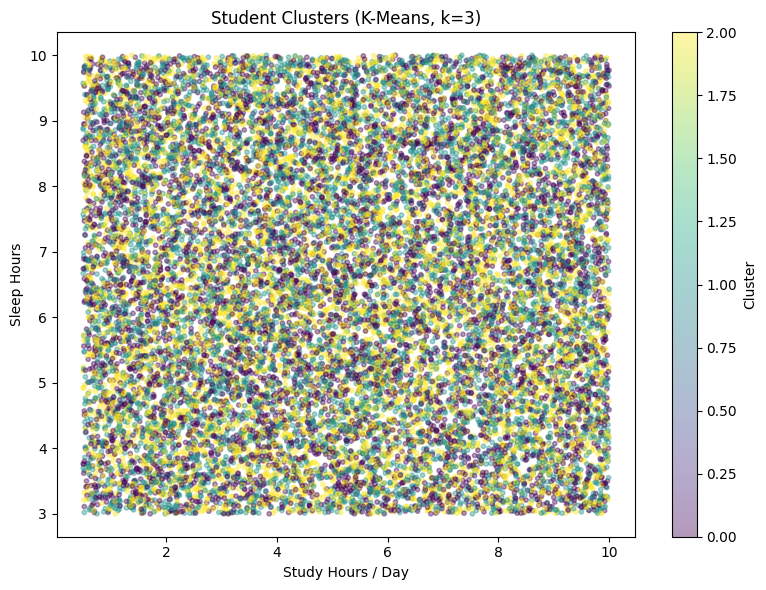

Silhouette Score: 0.3415

Frequent Itemsets (first 5):
   support        itemsets
0  0.42830     (SleepHigh)
1  0.52710     (StudyHigh)
2  0.37055     (SocialLow)
3  0.33585     (GamingLow)
4  0.75230  (ExerciseHigh)

Association Rules (antecedents → consequents | support, confidence, lift):
                                  antecedents        consequents  support  \
3                          (ProductivityHigh)        (StudyHigh)  0.11355   
26                (AttendanceHigh, StudyHigh)  (AssignmentsHigh)  0.13200   
28                (SocialLow, AttendanceHigh)     (ExerciseHigh)  0.11655   
20                     (StudyHigh, GamingLow)  (AssignmentsHigh)  0.10910   
25                     (StressLow, StudyHigh)  (AssignmentsHigh)  0.12760   
22                (AttendanceHigh, StudyHigh)     (ExerciseHigh)  0.16540   
39  (ExerciseHigh, StudyHigh, AttendanceHigh)  (AssignmentsHigh)  0.10000   
2                                 (StudyHigh)  (AssignmentsHigh)  0.31840   
11            

In [5]:
kmeans   = KMeans(n_clusters=3, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(X)
df["Cluster"] = clusters
print("First 5 rows with cluster labels:")
print(df[["study_hours_per_day", "sleep_hours", "Productivity", "Cluster"]].head())
 
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df["study_hours_per_day"], df["sleep_hours"],
    c=df["Cluster"], cmap="viridis", alpha=0.4, s=10
)
plt.colorbar(scatter, label="Cluster")
plt.xlabel("Study Hours / Day")
plt.ylabel("Sleep Hours")
plt.title("Student Clusters (K-Means, k=3)")
plt.tight_layout()
plt.show()
 
score = silhouette_score(X, clusters)
print("Silhouette Score:", round(score, 4))
 
# ---------- Association rules ----------
assoc_df = pd.DataFrame()
assoc_df["SleepHigh"]        = (df["sleep_hours"]           > 7)
assoc_df["StudyHigh"]        = (df["study_hours_per_day"]   > 5)
assoc_df["SocialLow"]        = (df["social_media_hours"]    < 3)
assoc_df["GamingLow"]        = (df["gaming_hours"]          < 2)
assoc_df["ExerciseHigh"]     = (df["exercise_minutes"]      >= 30)
assoc_df["StressLow"]        = (df["stress_level"]          <= 4)
assoc_df["AttendanceHigh"]   = (df["attendance_percentage"] >= 75)
assoc_df["AssignmentsHigh"]  = (df["assignments_completed"] >= 8)
assoc_df["ProductivityHigh"] = (df["Productivity"]          == "High")
 
frequent_itemsets = apriori(assoc_df, min_support=0.1, use_colnames=True)
print("\nFrequent Itemsets (first 5):")
print(frequent_itemsets.head())
 
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)
print("\nAssociation Rules (antecedents → consequents | support, confidence, lift):")
print(rules[["antecedents", "consequents", "support", "confidence", "lift"]]
      .sort_values("lift", ascending=False)
      .head(15))
 
 

In [6]:
best_model = rf_model   # ← Random Forest is the preferred model (see note below)
 
artifacts = {
    "model":                best_model,
    "productivity_encoder": productivity_encoder,
    "features":             FEATURES,          # stored so frontend always uses same order
}
 
with open("productivity_model.pkl", "wb") as f:
    pickle.dump(artifacts, f)
 
print("Model, encoder, and feature list saved to productivity_model.pkl")
 
# Quick sanity test
sample = pd.DataFrame([{
    "study_hours_per_day":    6.0,
    "sleep_hours":            7.5,
    "social_media_hours":     2.0,
    "gaming_hours":           1.0,
    "exercise_minutes":       40,
    "stress_level":           3,
    "assignments_completed":  9,
    "attendance_percentage":  85.0,
    "gender_enc":             1,    # 1 = Male (example)
}])
 
numeric_pred  = best_model.predict(sample)
label_pred    = productivity_encoder.inverse_transform(numeric_pred)
print("Sample input:\n", sample.T)
print("\nPredicted Productivity:", label_pred[0])

Model, encoder, and feature list saved to productivity_model.pkl
Sample input:
                           0
study_hours_per_day     6.0
sleep_hours             7.5
social_media_hours      2.0
gaming_hours            1.0
exercise_minutes       40.0
stress_level            3.0
assignments_completed   9.0
attendance_percentage  85.0
gender_enc              1.0

Predicted Productivity: Medium
